In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Thiết lập giao diện biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("==========================================================")
print(" DỰ ÁN: DỰ BÁO KIỆT QUỆ TÀI CHÍNH DOANH NGHIỆP (KẾ TOÁN)   ")
print("==========================================================")

# ==========================================
# 1. KHỞI TẠO DỮ LIỆU KẾ TOÁN GIẢ LẬP
# ==========================================
# Gợi ý: Khi nhóm có data thật, thay bằng: df = pd.read_csv('data/dulieuketoan.csv')
np.random.seed(42)
n_companies = 200

data = {
    'Ma_Doanh_Nghiep': [f'DN_{i:03d}' for i in range(1, n_companies + 1)],
    'X1_ROA': np.random.uniform(-0.15, 0.25, n_companies),          # Tỷ suất sinh lời trên tài sản
    'X2_Ty_le_No_vay': np.random.uniform(0.1, 0.85, n_companies),    # Nợ phải trả / Tổng tài sản
    'X3_Thanh_toan_Hien_hanh': np.random.uniform(0.4, 3.5, n_companies), # Tài sản ngắn hạn / Nợ ngắn hạn
    'X4_Vong_quay_Ton_kho': np.random.uniform(1.0, 12.0, n_companies),  # Giá vốn hàng bán / Hàng tồn kho bình quân
    'X5_Bien_LN_Gop': np.random.uniform(0.02, 0.45, n_companies)     # Lợi nhuận gộp / Doanh thu thuần
}
df = pd.DataFrame(data)

# Tạo logic thực tế cho biến mục tiêu 'Kiet_Que' (1: Kiệt quệ / Rủi ro phá sản, 0: An toàn)
# Doanh nghiệp có Nợ vay cao (X2) và ROA âm (X1) hoặc Khả năng thanh toán kém (X3) sẽ có rủi ro cao
score = df['X2_Ty_le_No_vay'] * 3.5 - df['X1_ROA'] * 5.0 - df['X3_Thanh_toan_Hien_hanh'] * 1.5
df['Kiet_Que'] = (score > 1.2).astype(int)

# Bổ sung một vài giá trị khuyết (NaN) để thực hiện bước Tiền xử lý dữ liệu kế toán
df.loc[df.sample(frac=0.03, random_seed=42).index, 'X1_ROA'] = np.nan

print(f"\n[+] Khởi tạo thành công dữ liệu của {n_companies} doanh nghiệp.")
print(f"[-] Số lượng doanh nghiệp bị kiệt quệ tài chính: {df['Kiet_Que'].sum()} DN")


# ==========================================
# 2. TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)
# ==========================================
print("\n--- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---")

# 2.1 Xử lý giá trị khuyết (Imputation) bằng phương pháp điền giá trị Trung vị (Median)
if df.isnull().sum().sum() > 0:
    print(f"-> Phát hiện giá trị khuyết: \n{df.isnull().sum()[df.isnull().sum() > 0]}")
    df['X1_ROA'] = df['X1_ROA'].fillna(df['X1_ROA'].median())
    print("-> Đã xử lý giá trị khuyết bằng giá trị Trung vị (Median) thành công.")


# ==========================================
# 3. PHÂN TÍCH KHÁM PHÁ (EDA) & TRỰC QUAN HÓA
# ==========================================
print("\n--- BƯỚC 3: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) ---")

# Biểu đồ 1: Ma trận tương quan giữa các chỉ số tài chính
plt.figure(figsize=(8, 6))
features_corr = ['X1_ROA', 'X2_Ty_le_No_vay', 'X3_Thanh_toan_Hien_hanh', 'X4_Vong_quay_Ton_kho', 'X5_Bien_LN_Gop']
sns.heatmap(df[features_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Ma Trận Tương Quan Các Chỉ Số Tài Chính Kế Toán', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Biểu đồ 2: Phân phối của Tỷ lệ Nợ vay giữa nhóm An toàn và Kiệt quệ
plt.figure(figsize=(9, 5))
sns.boxplot(x='Kiet_Que', y='X2_Ty_le_No_vay', data=df, palette='Set2')
plt.xticks([0, 1], ['An toàn (0)', 'Kiệt quệ (1)'])
plt.xlabel('Trạng thái Doanh nghiệp')
plt.ylabel('Tỷ lệ Nợ vay (X2)')
plt.title('So Sánh Tỷ Lệ Nợ Vay Giữa Nhóm Doanh Nghiệp', fontsize=14, fontweight='bold')
plt.show()


# ==========================================
# 4. XÂY DỰNG MÔ HÌNH DỰ BÁO (MACHINE LEARNING)
# ==========================================
print("\n--- BƯỚC 4: XÂY DỰNG MÔ HÌNH LOGISTIC REGRESSION ---")

# Tách biến độc lập (X) và biến phụ thuộc (y)
X = df[features_corr]
y = df['Kiet_Que']

# Chia dữ liệu thành 2 tập: Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu (Feature Scaling) để thuật toán chạy ổn định
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình hồi quy Logistic
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Dự báo trên tập kiểm tra (Test)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("[+] Huấn luyện mô hình hoàn tất.")


# ==========================================
# 5. ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH
# ==========================================
print("\n--- BƯỚC 5: ĐÁNH GIÁ HIỆU NĂNG DỰ BÁO ---")

# Hiển thị Báo cáo phân loại (Precision, Recall, F1-score)
print("\n[Báo cáo chi tiết phân loại]:")
print(classification_report(y_test, y_pred))

# Vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['An toàn', 'Kiệt quệ'], yticklabels=['An toàn', 'Kiệt quệ'])
plt.xlabel('Dự đoán từ Mô hình')
plt.ylabel('Thực tế Doanh nghiệp')
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Tính toán và vẽ đường cong ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Đường cong ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (FPR)')
plt.ylabel('Tỷ lệ Dương tính thật (TPR)')
plt.title('Đường Cong ROC & Chỉ Số AUC', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\n[=>] Chỉ số AUC cuối cùng của mô hình: {auc_score:.4f} (Chỉ số càng gần 1, mô hình dự báo càng chính xác).")
print("\n================ DỰ ÁN HOÀN THÀNH ================")

 DỰ ÁN: DỰ BÁO KIỆT QUỆ TÀI CHÍNH DOANH NGHIỆP (KẾ TOÁN)   


TypeError: NDFrame.sample() got an unexpected keyword argument 'random_seed'

 DỰ ÁN: DỰ BÁO KIỆT QUỆ TÀI CHÍNH DOANH NGHIỆP (KẾ TOÁN)   

[+] Khởi tạo thành công dữ liệu của 200 doanh nghiệp.
[-] Số lượng doanh nghiệp bị kiệt quệ tài chính: 11 DN

--- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---
-> Phát hiện giá trị khuyết: 
X1_ROA    6
dtype: int64
-> Đã xử lý giá trị khuyết bằng giá trị Trung vị (Median) thành công.

--- BƯỚC 3: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) ---


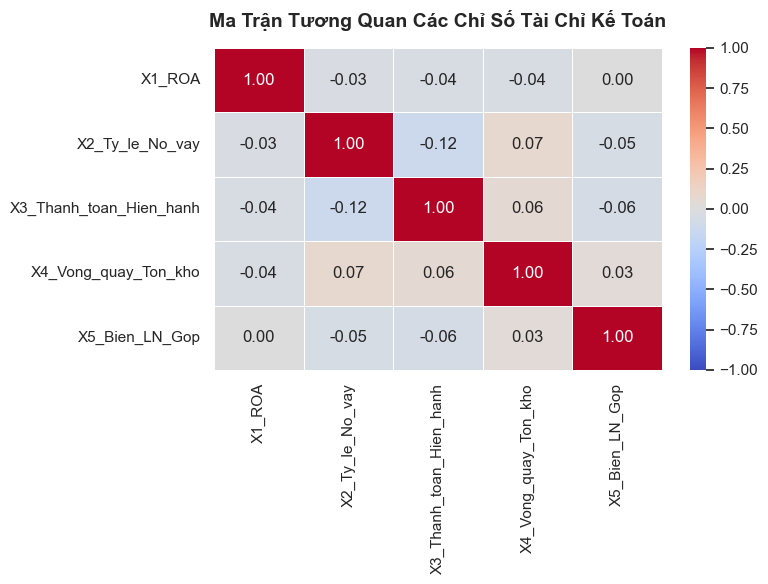

C:\Users\Admin\AppData\Local\Temp\ipykernel_22964\633169764.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kiet_Que', y='X2_Ty_le_No_vay', data=df, palette='Set2')


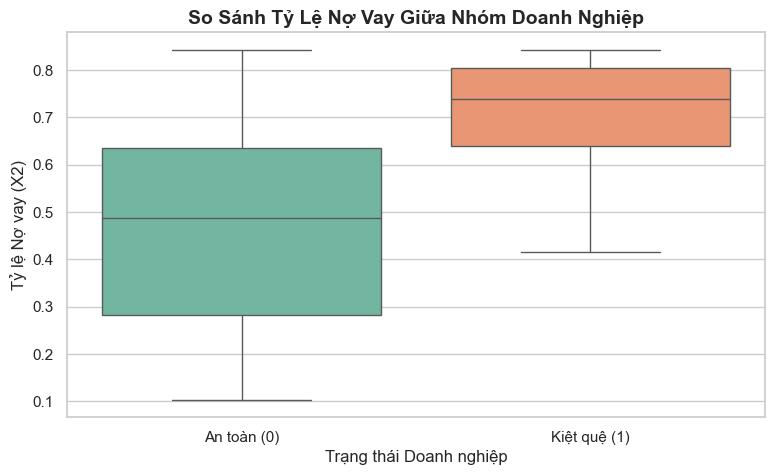


--- BƯỚC 4: XÂY DỰNG MÔ HÌNH LOGISTIC REGRESSION ---
[+] Huấn luyện mô hình hoàn tất.

--- BƯỚC 5: ĐÁNH GIÁ HIỆU NĂNG DỰ BÁO ---

[Báo cáo chi tiết phân loại]:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        38
           1       0.00      0.00      0.00         2

    accuracy                           0.95        40
   macro avg       0.47      0.50      0.49        40
weighted avg       0.90      0.95      0.93        40



c:\Users\Admin\miniconda3\envs\distress_prediction\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\miniconda3\envs\distress_prediction\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\miniconda3\envs\distress_prediction\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

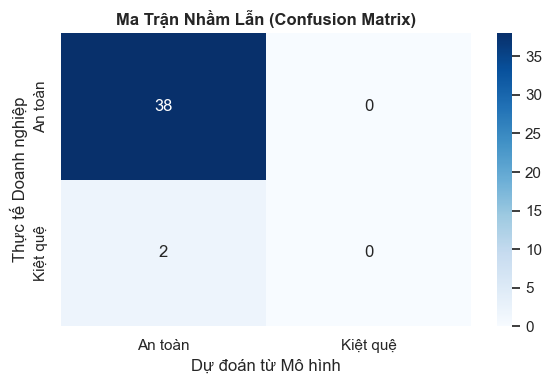

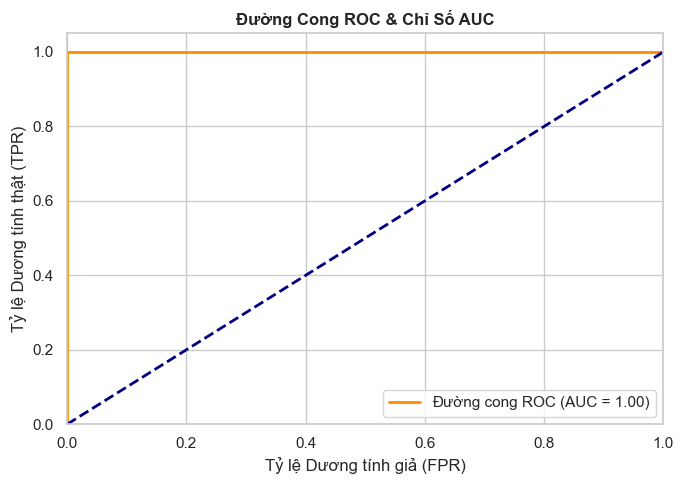


[=>] Chỉ số AUC cuối cùng của mô hình: 1.0000

================ DỰ ÁN HOÀN THÀNH ================


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Thiết lập giao diện biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("==========================================================")
print(" DỰ ÁN: DỰ BÁO KIỆT QUỆ TÀI CHÍNH DOANH NGHIỆP (KẾ TOÁN)   ")
print("==========================================================")

# ==========================================
# 1. KHỞI TẠO DỮ LIỆU KẾ TOÁN GIẢ LẬP
# ==========================================
np.random.seed(42)
n_companies = 200

data = {
    'Ma_Doanh_Nghiep': [f'DN_{i:03d}' for i in range(1, n_companies + 1)],
    'X1_ROA': np.random.uniform(-0.15, 0.25, n_companies),          
    'X2_Ty_le_No_vay': np.random.uniform(0.1, 0.85, n_companies),    
    'X3_Thanh_toan_Hien_hanh': np.random.uniform(0.4, 3.5, n_companies), 
    'X4_Vong_quay_Ton_kho': np.random.uniform(1.0, 12.0, n_companies),  
    'X5_Bien_LN_Gop': np.random.uniform(0.02, 0.45, n_companies)     
}
df = pd.DataFrame(data)

# Tạo logic thực tế cho biến mục tiêu 'Kiet_Que' (1: Kiệt quệ, 0: An toàn)
score = df['X2_Ty_le_No_vay'] * 3.5 - df['X1_ROA'] * 5.0 - df['X3_Thanh_toan_Hien_hanh'] * 1.5
df['Kiet_Que'] = (score > 1.2).astype(int)

# --- ĐÃ SỬA LỖI Ở ĐÂY: Đổi 'random_seed' thành 'random_state' ---
df.loc[df.sample(frac=0.03, random_state=42).index, 'X1_ROA'] = np.nan

print(f"\n[+] Khởi tạo thành công dữ liệu của {n_companies} doanh nghiệp.")
print(f"[-] Số lượng doanh nghiệp bị kiệt quệ tài chính: {df['Kiet_Que'].sum()} DN")


# ==========================================
# 2. TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)
# ==========================================
print("\n--- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---")

# Xử lý giá trị khuyết (Imputation) bằng phương pháp điền giá trị Trung vị (Median)
if df.isnull().sum().sum() > 0:
    print(f"-> Phát hiện giá trị khuyết: \n{df.isnull().sum()[df.isnull().sum() > 0]}")
    df['X1_ROA'] = df['X1_ROA'].fillna(df['X1_ROA'].median())
    print("-> Đã xử lý giá trị khuyết bằng giá trị Trung vị (Median) thành công.")


# ==========================================
# 3. PHÂN TÍCH KHÁM PHÁ (EDA) & TRỰC QUAN HÓA
# ==========================================
print("\n--- BƯỚC 3: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) ---")

features_corr = ['X1_ROA', 'X2_Ty_le_No_vay', 'X3_Thanh_toan_Hien_hanh', 'X4_Vong_quay_Ton_kho', 'X5_Bien_LN_Gop']

# Biểu đồ 1: Ma trận tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(df[features_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Ma Trận Tương Quan Các Chỉ Số Tài Chỉ Kế Toán', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Biểu đồ 2: Phân phối của Tỷ lệ Nợ vay
plt.figure(figsize=(9, 5))
sns.boxplot(x='Kiet_Que', y='X2_Ty_le_No_vay', data=df, palette='Set2')
plt.xticks([0, 1], ['An toàn (0)', 'Kiệt quệ (1)'])
plt.xlabel('Trạng thái Doanh nghiệp')
plt.ylabel('Tỷ lệ Nợ vay (X2)')
plt.title('So Sánh Tỷ Lệ Nợ Vay Giữa Nhóm Doanh Nghiệp', fontsize=14, fontweight='bold')
plt.show()


# ==========================================
# 4. XÂY DỰNG MÔ HÌNH DỰ BÁO (MACHINE LEARNING)
# ==========================================
print("\n--- BƯỚC 4: XÂY DỰNG MÔ HÌNH LOGISTIC REGRESSION ---")

X = df[features_corr]
y = df['Kiet_Que']

# Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
print("[+] Huấn luyện mô hình hoàn tất.")


# ==========================================
# 5. ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH
# ==========================================
print("\n--- BƯỚC 5: ĐÁNH GIÁ HIỆU NĂNG DỰ BÁO ---")

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\n[Báo cáo chi tiết phân loại]:")
print(classification_report(y_test, y_pred))

# Biểu đồ 3: Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['An toàn', 'Kiệt quệ'], yticklabels=['An toàn', 'Kiệt quệ'])
plt.xlabel('Dự đoán từ Mô hình')
plt.ylabel('Thực tế Doanh nghiệp')
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Biểu đồ 4: Đường cong ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Đường cong ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (FPR)')
plt.ylabel('Tỷ lệ Dương tính thật (TPR)')
plt.title('Đường Cong ROC & Chỉ Số AUC', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\n[=>] Chỉ số AUC cuối cùng của mô hình: {auc_score:.4f}")
print("\n================ DỰ ÁN HOÀN THÀNH ================")